In [1]:
import math

from common import *
from experiment import *
from data import RawData, PlottableData
from treatments.picoquic import treatment_map

In [11]:
def TREATMENTS():
    labels = [
        'picoquic',
        'picoquic_split',
        'picoquic_sidekick_0ms',
        'picoquic_sidekick_30ms',
        'picoquic_sidekick_60ms',
        # 'picoquic_sidekick_60ms_hint',
        'picoquic_iblt_0ms',
        'picoquic_iblt_30ms',
        'picoquic_iblt_60ms',
        # 'picoquic_iblt_60ms_hint',
    ]
    return [treatment_map[label] for label in labels]

# def BBR_TREATMENTS(cca):
#     treatments = TREATMENTS()
#     for treatment in treatments:
#         treatment._label += f'_{cca}'
#         treatment._protocol_options += ['-cca', cca]
#     return treatments

LOSS1_VALUES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=loss1, loss2=0)
        for loss1 in LOSS1_VALUES[:n]
    ]

def DATA_SIZES(bottleneck_bw=20):
    return [bottleneck_bw * 125000 * 10]

# Collect data for experiments

In [ ]:
# NOTE: We have to run one trial at a time with the sidekick since it can only handle one connection at a time,
# and it decides which connection to handle by the first UDP packet it observes
for i in range(1, 2):
    exp = Experiment(num_trials=i, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS()[:5], data_sizes=DATA_SIZES())
    picoquic_raw_data = RawData(exp, execute=True, max_networks={'picoquic': 6, 'picoquic_sidekick_0ms': 10})

12
sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 1 --loss2 0 -t 1 --label picoquic_iblt_0ms --network-statistics --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 80 --riblt picoquic --client-quacker --ack-delay 0 -n 25000000 13.132547378540039
sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 2 --loss2 0 -t 1 --label picoquic_iblt_0ms --network-statistics --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 80 --riblt picoquic --client-quacker --ack-delay 0 -n 25000000 13.067552089691162
sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 3 --loss2 0 -t 1 --label picoquic_iblt_0ms --network-statistics --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 80 --riblt picoquic --client-quacker --ack-delay 0 -n 25000000 

In [6]:
n = 10
exp = Experiment(num_trials=n, treatments=TREATMENTS(), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES())
picoquic_raw_data = RawData(exp, execute=False, max_networks={'picoquic': 6, 'picoquic_sidekick_0ms': 8})

MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 26 --loss2 0 -t 9 --label picoquic_sidekick_30ms --network-statistics --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 28 --loss2 0 -t 9 --label picoquic_sidekick_30ms --network-statistics --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 26 --loss2 0 -t 9 --label picoquic_sidekick_60ms --network-statistics --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 picoquic --client-quacker --ack-delay 60 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 28 --loss2 0 -t 9 --label picoquic_sidekick_60ms --network-statistics --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 

I tried collecting metrics for various protocols, since the sniffer and proxy are both protocol-agnostic:
* **picoquic** seems to work as expected.
* **Cloudflare quiche** connections as of last year continue to timeout non-deterministically, which makes it annoying to evaluate. I'm pretty sure this is their bug.
* **Google quiche** at greater than 3% loss has a client error QUIC_TOO_MANY_RTOS. When a packet is sent over the network and no acknowledgement is received within a certain time frame, a retransmission timeout (RTO) occurs. This error essentially indicates that the network connection was too slow or unreliable to maintain a stable data stream, causing the connection to time out and fail. I think this is occurring because the QUIC server is retransmitting data frames in _new_ packets, but the client may be receiving the proxy-retransmitted _original_ packets and not properly acknowledging real retransmissions.
* **TCP** won't be recognized because the sniffers have been implemented to only look at UDP packets. However, this isn't fundamental and we could theoretically modify both to consider _all_ packets.

# Plot network metrics

## Plotting functions

In [8]:
def plot_loss_vs_metric_line(data, title, ylabel, delta=25):
    plt.figure(figsize=(6, 4))
    
    labels = data.treatments
    assert len(data.data_sizes) == 1
    data_size = data.data_sizes[0]

    # Plot each label
    for label in labels:
        xs = []
        ys_raw = []

        for network in data.network_settings:
            if data_size not in data.data[label][network]:
                continue
            network_setting = data.exp.get_network_setting(network)
            xs.append(float(network_setting.settings['loss1']))
            ys_raw.append(data.data[label][network][data_size])

        ys = [y.p(50) for y in ys_raw]
        yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
        yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
        plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker='.', capsize=5, label=label)

    plt.title(title)
    plt.xlabel('Loss % near data receiver')
    plt.ylabel(ylabel)
    plt.grid()
    plt.xlim(0)
    plt.ylim(0)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    plt.show()

## Throughput

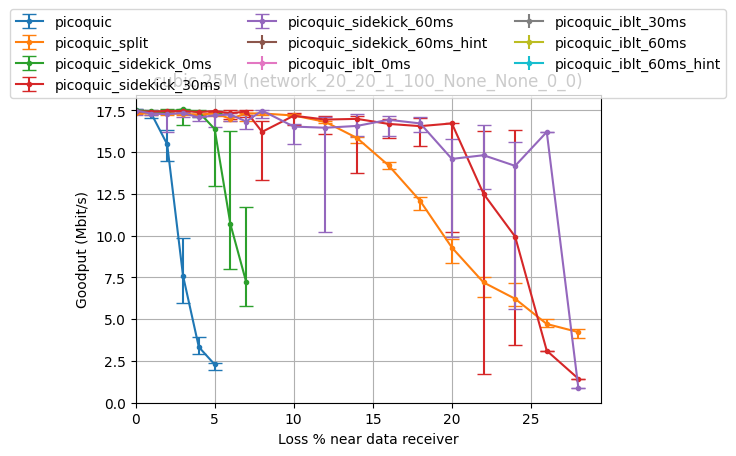

In [9]:
def plot_loss_vs_throughput(prefix, raw_data):
    title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
    ylabel = 'Goodput (Mbit/s)'
    plottable_data = PlottableData(raw_data, 'throughput_mbps')
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=ylabel)

plot_loss_vs_throughput('cubic', picoquic_raw_data)
# plot_loss_vs_throughput('bbr1', bbr1_raw_data)
# plot_loss_vs_throughput('bbr3', bbr3_raw_data)
# plot_loss_vs_throughput('tcp', tcp_raw_data)
# plot_loss_vs_throughput('chromium', chromium_raw_data)

In [30]:
def plot_loss_vs_num_spurious(prefix, raw_data, sender: bool):
    key = 'Sender' if sender else 'Receiver'
    def num_spurious_func(output):
        if 'additional_data' not in output:
            return 0
        data_key = f'num_spurious_{key.lower()}'
        if data_key not in output['additional_data']:
            print(output['additional_data'])
        return output['additional_data'][data_key]
    
    title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
    plottable_data = PlottableData(raw_data, num_spurious_func)
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=f'Num Spurious Retransmissions ({key})')

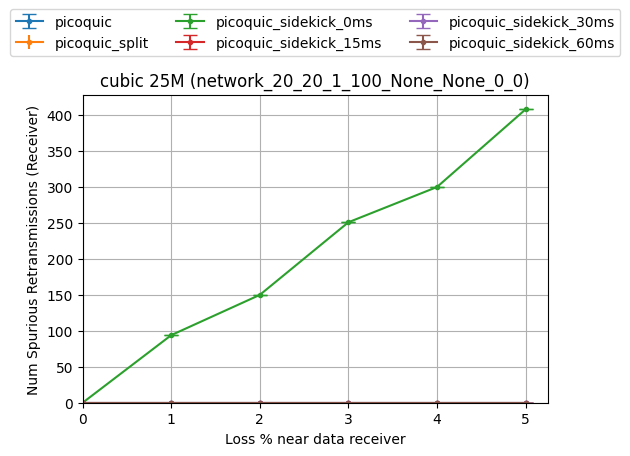

In [31]:
plot_loss_vs_num_spurious('cubic', picoquic_raw_data, sender=False)
# plot_loss_vs_num_spurious('bbr1', bbr1_raw_data, sender=False)
# plot_loss_vs_num_spurious('bbr3', bbr3_raw_data, sender=False)
# plot_loss_vs_num_spurious('picoquic', picoquic_raw_data, sender=True)

In [10]:
def plot_loss_vs_network_metric(prefix, raw_data, metric):
    def metric_func(iface, metric):
        def func(output):
            statistics = output['statistics']
            iface_index = statistics['ifaces'].index(iface)
            return statistics[metric][iface_index]
        return func

    for iface in ['h1-eth0', 'p1-eth1', 'h2-eth0', 'p1-eth0']:
        title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
        ylabel = f'{iface} {metric}'
        plottable_data = PlottableData(raw_data, metric_func(iface, metric))
        plot_loss_vs_metric_line(plottable_data, title=title, ylabel=ylabel)

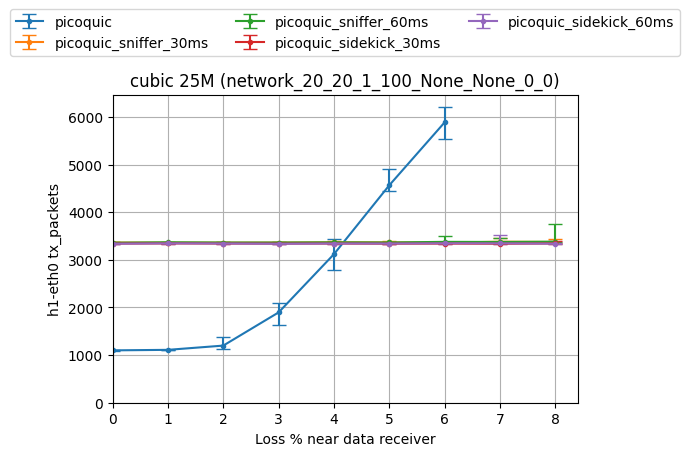

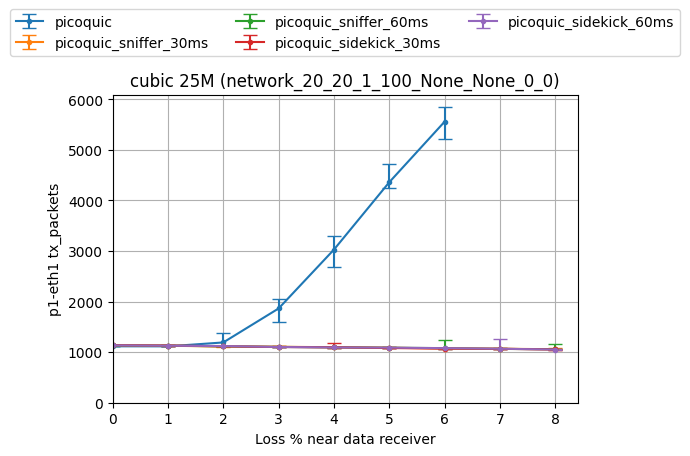

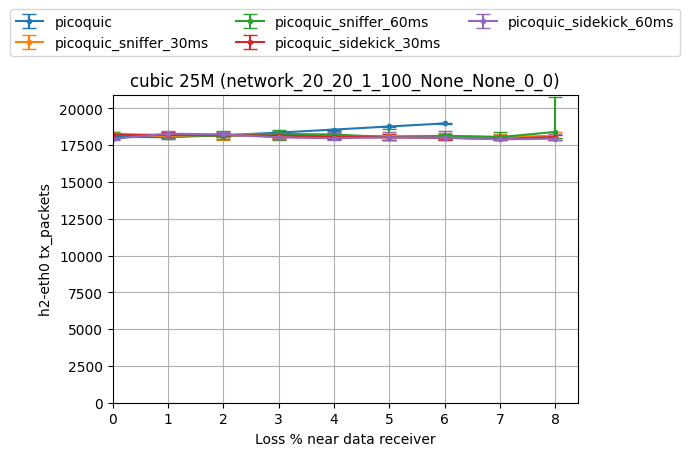

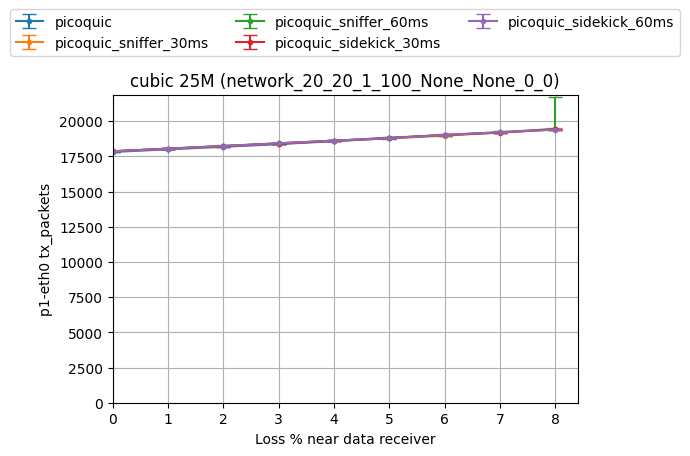

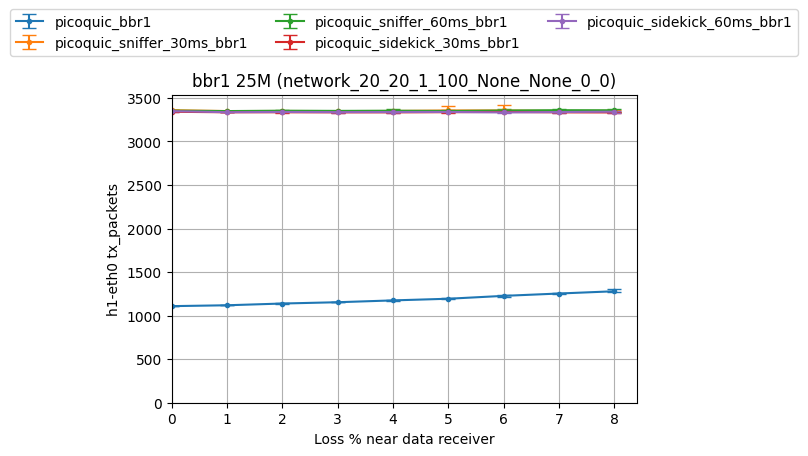

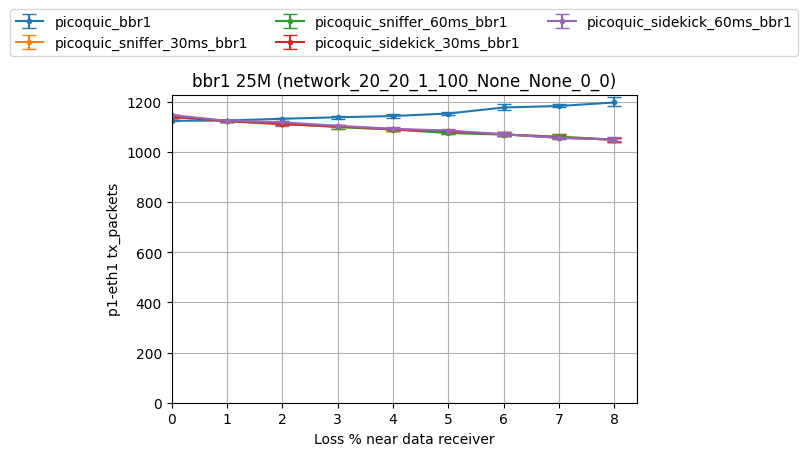

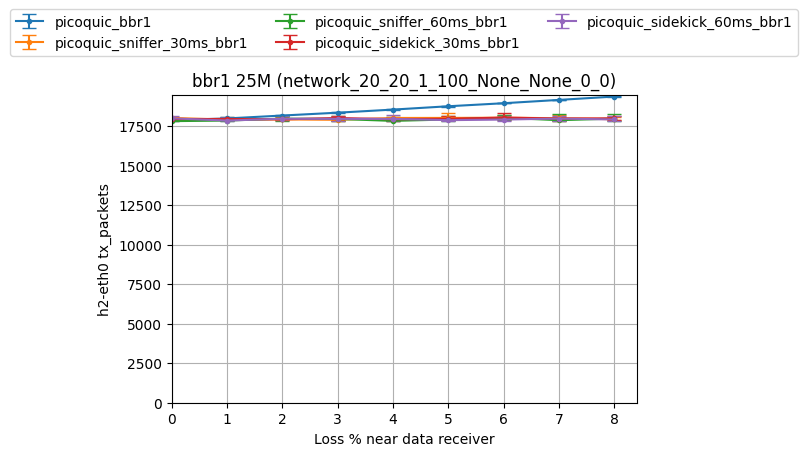

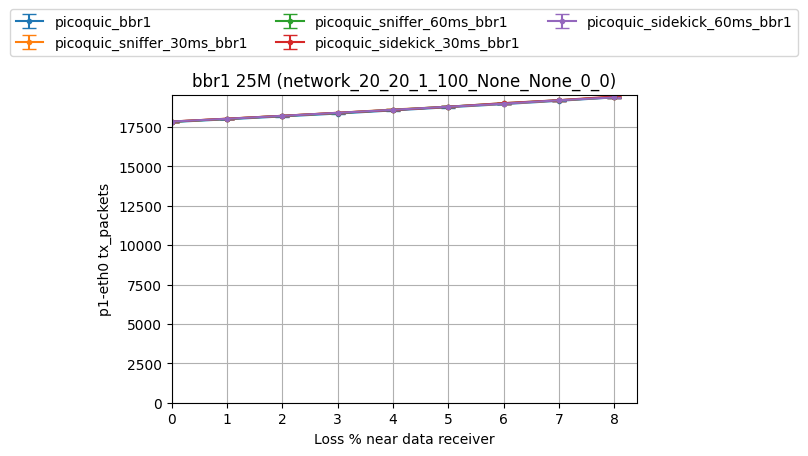

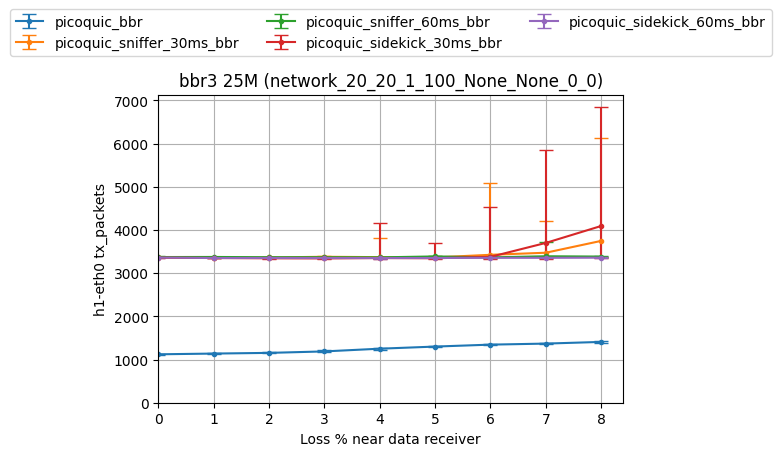

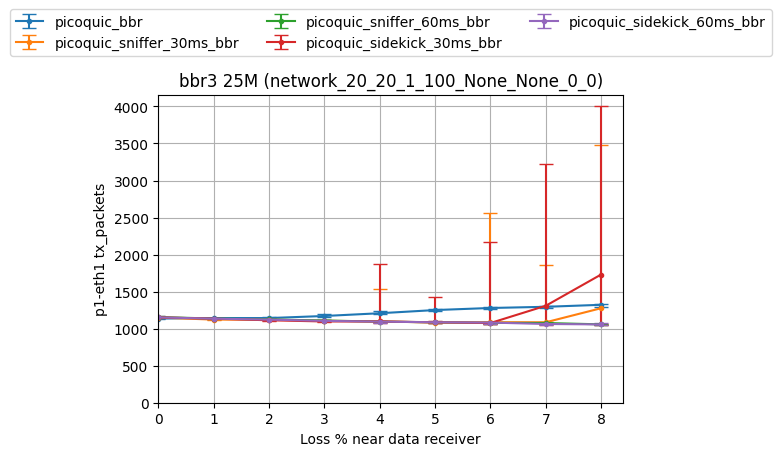

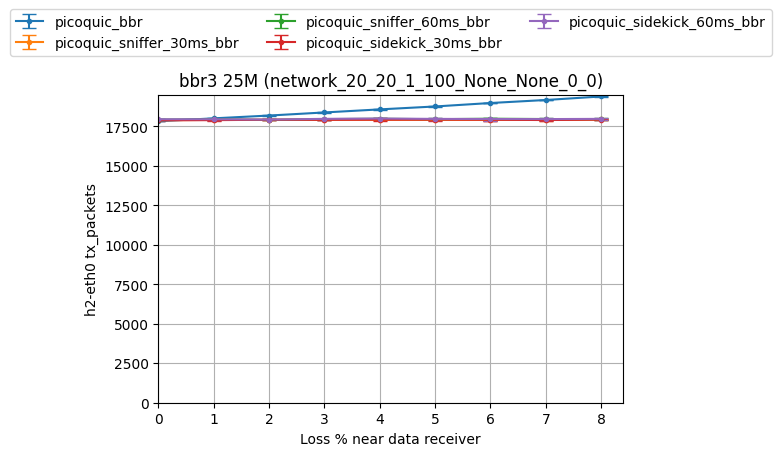

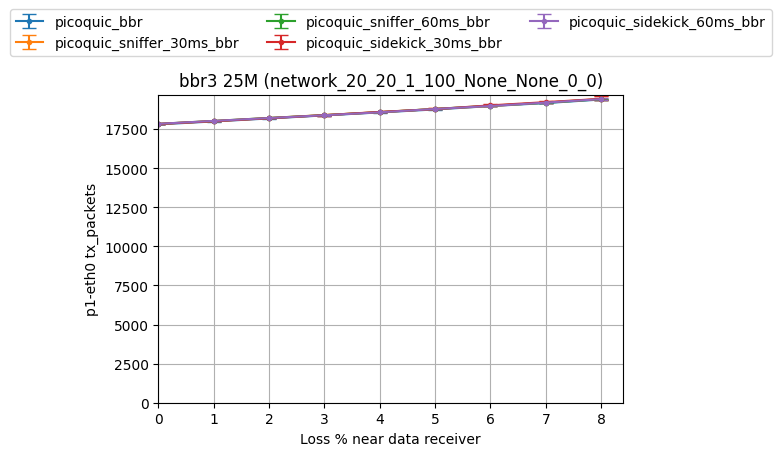

In [11]:
plot_loss_vs_network_metric('cubic', picoquic_raw_data, 'tx_packets')
plot_loss_vs_network_metric('bbr1', bbr1_raw_data, 'tx_packets')
plot_loss_vs_network_metric('bbr3', bbr3_raw_data, 'tx_packets')